In [1]:
import requests
from tqdm import tqdm
from muon import MuData
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import mudata as md
# import shutil
import re

In [2]:
from oscb.data import DataLoader
from oscb.evaluator import eval, write_json
from oscb.utilization import Monitor

/opt/conda/lib/python3.11/site-packages/grakel/kernels/graph_hopper.py:9: PendingDeprecationWarning: Importing from numpy.matlib is deprecated since 1.19.0. The matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray. 
  from numpy.matlib import repmat


In [3]:
adata = DataLoader("CL-m-FACS_Bladder-1268-Tabula-2018", data_folder='/ps/downloads/')
adata

{'date': 'Wed, 24 Sep 2025 01:49:32 GMT', 'server': 'uvicorn', 'content-disposition': 'attachment; filename=facs_Bladder_Seurat.h5ad', 'content-type': 'application/octet-stream', 'x-process-time': '0.0024 sec', 'transfer-encoding': 'chunked'}


facs_Bladder_Seurat.h5ad: 23.3MB [00:00, 91.1MB/s]


File downloaded successfully to: downloads/facs_Bladder_Seurat.h5ad


AnnData object with n_obs × n_vars = 1268 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

/tmp/ipykernel_2080/2023949081.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


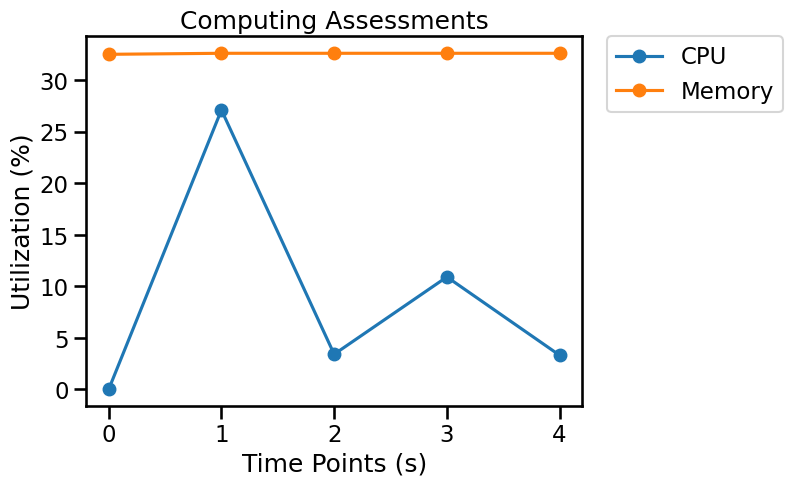

{'sys_info': {'CPU': 'x86_64 16-core @ 1.27 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0, 27.1, 3.4, 10.9, 3.3],
 'Memory': [32.5, 32.6, 32.6, 32.6, 32.6],
 'GPU': [0, 0, 0, 0, 0],
 'GPU Memory': [1.46, 1.46, 1.46, 1.46, 1.46],
 'time_points': [1758678573.1171024,
  1758678574.2672713,
  1758678575.4447289,
  1758678576.569928,
  1758678578.1120505]}

In [4]:
monitor = Monitor(1)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.tl.leiden(adata)
monitor.stop()

Clustering Scores:
Silhouette: 0.7259
NMI: 0.5057
ARI: 0.2741
Fowlkes Mallows: 0.5239


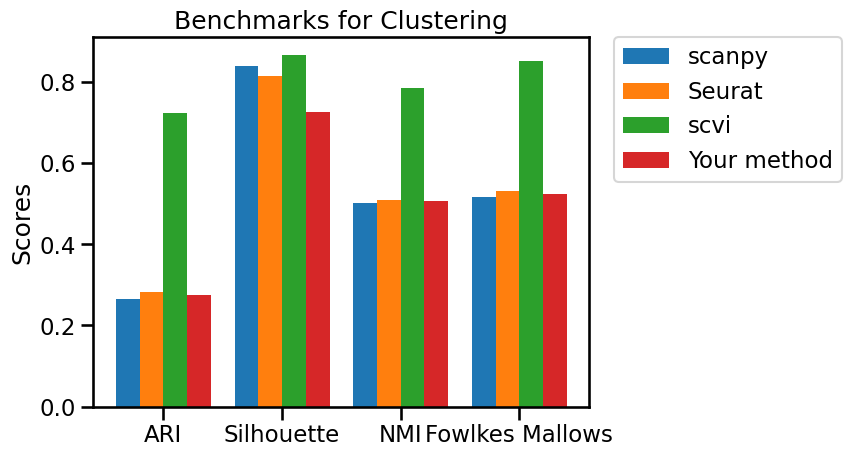

{'benchmarksId': 'CL-m-FACS_Bladder-1268-Tabula-2018',
 'datasetId': 'm-FACS_Bladder-1268-Tabula-2018',
 'task_type': 'Clustering',
 'tool': 'Your method',
 'Silhouette': 0.7259,
 'NMI': 0.5057,
 'ARI': 0.2741,
 'Fowlkes Mallows': 0.5239,
 'created_on': datetime.datetime(2025, 9, 23, 20, 49, 38, 307211)}

In [5]:
results = eval(adata, benchmarks_id="CL-m-FACS_Bladder-1268-Tabula-2018", cluster_key='leiden', embedding_key='X_umap')
results

In [6]:
write_json(results)

Dictionary successfully written to ./output.json


In [9]:
import json
from datetime import datetime

def serialize_datetime(obj):
    if isinstance(obj, datetime):
        return obj.isoformat()
    raise TypeError("Type not serializable")

In [10]:
def write_json(data, file_path="./output.json"):
    # Open the file in write mode ('w') and use json.dump() to write the dictionary
    with open(file_path, 'w') as json_file:
        json.dump(data, json_file, indent=4, default=serialize_datetime) # indent=4 for pretty-printing

    print(f"Dictionary successfully written to {file_path}")